# 04 KNeighborsClassifier Model Selection

In diesem Notebook wird der KNeighborsClassifier mit Group Cross-Validation nach `subject` bewertet. Anschließend wird das beste kNN-Modell auf dem festgelegten Testset mit den Subjects 27 bis 30 ausgewertet.

In [1]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

PROCESSED_DIR = Path("../../data/processed")
RESULTS_DIR = Path("../../results")
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## Daten laden

In [2]:
train_data = pd.read_csv(PROCESSED_DIR / "train_data.csv")
test_data = pd.read_csv(PROCESSED_DIR / "test_data.csv")

with open(PROCESSED_DIR / "feature_columns.txt", "r", encoding="utf-8") as f:
    feature_cols = [line.strip() for line in f]

print("Train data:", train_data.shape)
print("Test data:", test_data.shape)
print("Anzahl Features:", len(feature_cols))

Train data: (5867, 563)
Test data: (1485, 563)
Anzahl Features: 561


## Features, Zielvariable und Groups definieren

In [3]:
target_col = "activity"
group_col = "subject"

X_train = train_data[feature_cols]
y_train = train_data[target_col]
groups_train = train_data[group_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("groups_train:", groups_train.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (5867, 561)
y_train: (5867,)
groups_train: (5867,)

X_test: (1485, 561)
y_test: (1485,)


## kNN-Pipeline definieren

kNN basiert auf Abständen zwischen Beobachtungen. Deshalb wird das Modell mit `StandardScaler` in einer Pipeline kombiniert.

In [4]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",3

## Cross-Validation und Hyperparameter-Suche

Die Modellwahl erfolgt mit 5-fold Group Cross-Validation. Die Gruppierung erfolgt nach `subject`, damit Messungen derselben Person nicht gleichzeitig in Trainings- und Validierungsdaten vorkommen.

In [5]:
cv = GroupKFold(n_splits=5)

knn_param_distributions = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"],
}

In [6]:
knn_random_search = RandomizedSearchCV(
    estimator=knn_pipeline,
    param_distributions=knn_param_distributions,
    n_iter=10,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True,
)

knn_random_search.fit(
    X_train,
    y_train,
    groups=groups_train,
)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... vers

## Beste Parameter und Cross-Validation-Ergebnis

In [7]:
print("Beste Parameter:")
print(knn_random_search.best_params_)

print("\nBeste CV Accuracy:")
print(knn_random_search.best_score_)

print("\nBester CV Error:")
print(1 - knn_random_search.best_score_)

Beste Parameter:
{'model__weights': 'distance', 'model__n_neighbors': 15, 'model__metric': 'manhattan'}

Beste CV Accuracy:
0.8757917254208962

Bester CV Error:
0.12420827457910377


## Suchergebnisse als Tabelle

In [8]:
knn_search_results = pd.DataFrame(knn_random_search.cv_results_)

selected_columns = [
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "mean_fit_time",
    "mean_score_time",
    "params",
]

knn_search_results_table = knn_search_results[selected_columns].sort_values(
    by="mean_test_score",
    ascending=False,
)

knn_search_results_table.head(10)

,mean_test_score,std_test_score,mean_train_score,std_train_score,mean_fit_time,mean_score_time,params
1,0.875792,0.033471,1.000000,0.000000,0.208922,4.218977,"{'model__weights': 'distance', 'model__n_neigh..."
7,0.872441,0.032271,0.982073,0.001789,0.196867,3.999378,"{'model__weights': 'uniform', 'model__n_neighb..."
3,0.871102,0.036060,1.000000,0.000000,0.206838,3.738257,"{'model__weights': 'distance', 'model__n_neigh..."
6,0.866001,0.034830,1.000000,0.000000,0.154591,3.793011,"{'model__weights': 'distance', 'model__n_neigh..."
8,0.858395,0.046643,1.000000,0.000000,0.205195,0.198385,"{'model__weights': 'distance', 'model__n_neigh..."
9,0.857030,0.048097,1.000000,0.000000,0.168368,0.211851,"{'model__weights': 'distance', 'model__n_neigh..."
5,0.856948,0.048278,0.959930,0.004344,0.173570,0.215995,"{'model__weights': 'uniform', 'model__n_neighb..."
0,0.856054,0.043174,1.000000,0.000000,0.240188,0.391123,"{'model__weights': 'distance', 'model__n_neigh..."
2,0.855042,0.043114,0.972708,0.001611,0.191049,0.236091,"{'model__weights': 'uniform', 'model__n_neighb..."
4,0.834158,0.040014,0.991122,0.001452,0.181654,0.222068,"{'model__weights': 'uniform', 'model__n_neighb..."


## Ergebnisse speichern

In [9]:
knn_search_results_table.to_csv(
    TABLE_DIR / "knn_random_search_results.csv",
    index=False,
)

print("Gespeichert:", TABLE_DIR / "knn_random_search_results.csv")

Gespeichert: ..\..\results\tables\knn_random_search_results.csv


## Bestes kNN-Modell erneut mit Cross-Validation auswerten

In [10]:
best_knn_model = knn_random_search.best_estimator_

knn_cv_results = cross_validate(
    best_knn_model,
    X_train,
    y_train,
    groups=groups_train,
    cv=cv,
    scoring="accuracy",
    return_train_score=True,
    n_jobs=-1,
)

knn_summary = pd.DataFrame({
    "model": ["KNeighborsClassifier_tuned"],
    "mean_cv_accuracy": [knn_cv_results["test_score"].mean()],
    "std_cv_accuracy": [knn_cv_results["test_score"].std()],
    "mean_cv_error": [1 - knn_cv_results["test_score"].mean()],
    "mean_train_accuracy": [knn_cv_results["train_score"].mean()],
    "mean_fit_time": [knn_cv_results["fit_time"].mean()],
    "mean_score_time": [knn_cv_results["score_time"].mean()],
})

knn_summary

,model,mean_cv_accuracy,std_cv_accuracy,mean_cv_error,mean_train_accuracy,mean_fit_time,mean_score_time
0,KNeighborsClassifier_tuned,0.875792,0.033471,0.124208,1.0,0.141528,3.812221


## CV-Zusammenfassung speichern

In [11]:
knn_summary.to_csv(
    TABLE_DIR / "knn_tuned_cv_summary.csv",
    index=False,
)

print("Gespeichert:", TABLE_DIR / "knn_tuned_cv_summary.csv")

Gespeichert: ..\..\results\tables\knn_tuned_cv_summary.csv


## Bewertung auf dem Testset

Nach der Modellwahl wird das beste kNN-Modell auf den Trainingsdaten trainiert und anschließend auf dem festgelegten Testset mit den Subjects 27 bis 30 bewertet.

In [12]:
best_knn_model.fit(X_train, y_train)

y_pred_knn = best_knn_model.predict(X_test)

knn_test_accuracy = accuracy_score(y_test, y_pred_knn)
knn_test_error = 1 - knn_test_accuracy

print("Test Accuracy:", round(knn_test_accuracy, 4))
print("Test Error:", round(knn_test_error, 4))

Test Accuracy: 0.9259
Test Error: 0.0741


## Classification Report

In [13]:
knn_report = classification_report(
    y_test,
    y_pred_knn,
    output_dict=True,
)

knn_report_df = pd.DataFrame(knn_report).transpose()
knn_report_df

,precision,recall,f1-score,support
LAYING,1.000000,0.880546,0.936479,293.000000
SITTING,0.959091,0.799242,0.871901,264.000000
STANDING,0.762431,0.975265,0.855814,283.000000
WALKING,0.987013,0.995633,0.991304,229.000000
WALKING_DOWNSTAIRS,1.000000,0.930000,0.963731,200.000000
WALKING_UPSTAIRS,0.947368,1.000000,0.972973,216.000000
accuracy,0.925926,0.925926,0.925926,0.925926
macro avg,0.942651,0.930114,0.932034,1485.000000
weighted avg,0.937795,0.925926,0.927059,1485.000000


In [14]:
knn_report_df.to_csv(
    TABLE_DIR / "knn_tuned_classification_report.csv",
    index=True,
)

print("Gespeichert:", TABLE_DIR / "knn_tuned_classification_report.csv")

Gespeichert: ..\..\results\tables\knn_tuned_classification_report.csv


## Confusion Matrix

Die Confusion Matrix zeigt, welche echten Klassen welchen vorhergesagten Klassen zugeordnet wurden.

In [15]:
labels = sorted(y_train.unique())

knn_cm = confusion_matrix(
    y_test,
    y_pred_knn,
    labels=labels,
)

knn_cm_table = pd.DataFrame(
    knn_cm,
    index=[f"True: {label}" for label in labels],
    columns=[f"Pred: {label}" for label in labels],
)

knn_cm_table

,Pred: LAYING,Pred: SITTING,Pred: STANDING,Pred: WALKING,Pred: WALKING_DOWNSTAIRS,Pred: WALKING_UPSTAIRS
True: LAYING,258,2,33,0,0,0
True: SITTING,0,211,53,0,0,0
True: STANDING,0,7,276,0,0,0
True: WALKING,0,0,0,228,0,1
True: WALKING_DOWNSTAIRS,0,0,0,3,186,11
True: WALKING_UPSTAIRS,0,0,0,0,0,216


In [16]:
knn_cm_table.to_csv(
    TABLE_DIR / "knn_tuned_confusion_matrix.csv",
    index=True,
)

print("Gespeichert:", TABLE_DIR / "knn_tuned_confusion_matrix.csv")

Gespeichert: ..\..\results\tables\knn_tuned_confusion_matrix.csv


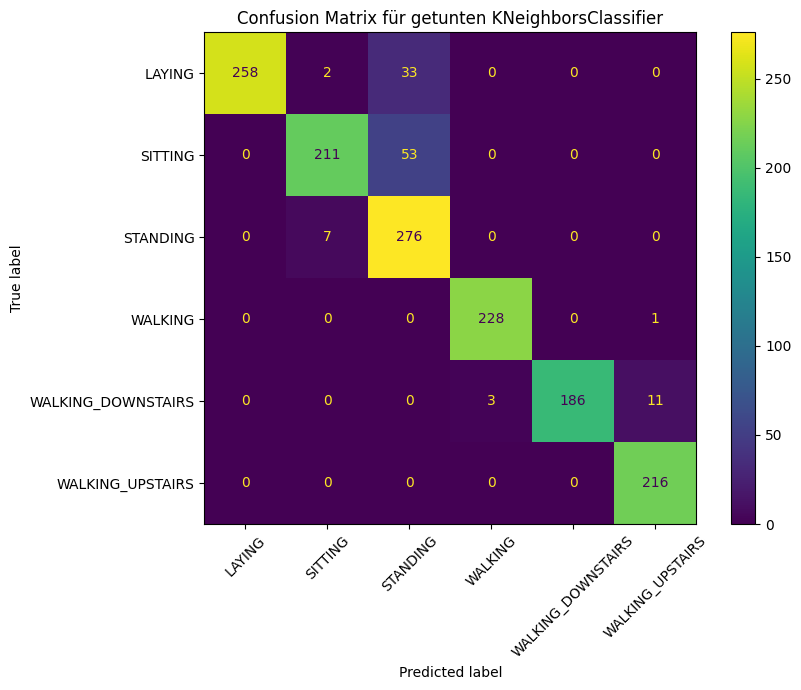

In [17]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=labels,
)

fig, ax = plt.subplots(figsize=(9, 7))

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
)

plt.title("Confusion Matrix für getunten KNeighborsClassifier")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "knn_tuned_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Testmetriken speichern

In [18]:
knn_test_metrics = pd.DataFrame({
    "model": ["KNeighborsClassifier_tuned"],
    "test_accuracy": [knn_test_accuracy],
    "test_error": [knn_test_error],
    "n_test_observations": [len(y_test)],
})

knn_test_metrics.to_csv(
    TABLE_DIR / "knn_tuned_test_metrics.csv",
    index=False,
)

knn_test_metrics

,model,test_accuracy,test_error,n_test_observations
0,KNeighborsClassifier_tuned,0.925926,0.074074,1485
